<a href="https://colab.research.google.com/github/ArifahZhafirah/PEMBELAJARAN-MESIN/blob/main/JS05/TugasLab-01/PEMMES%20TUGAS%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Soal 1

#Langkah 1 - Load Data

In [29]:
import pandas as pd
data = pd.read_csv('voice.csv')
data.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


#Langkah 2 - Eksplorasi Data

In [30]:
data.info()
data.describe()
data['label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   obje

,count
label,
male,1584
female,1584


#Langkah 3 - Visualisasi Data

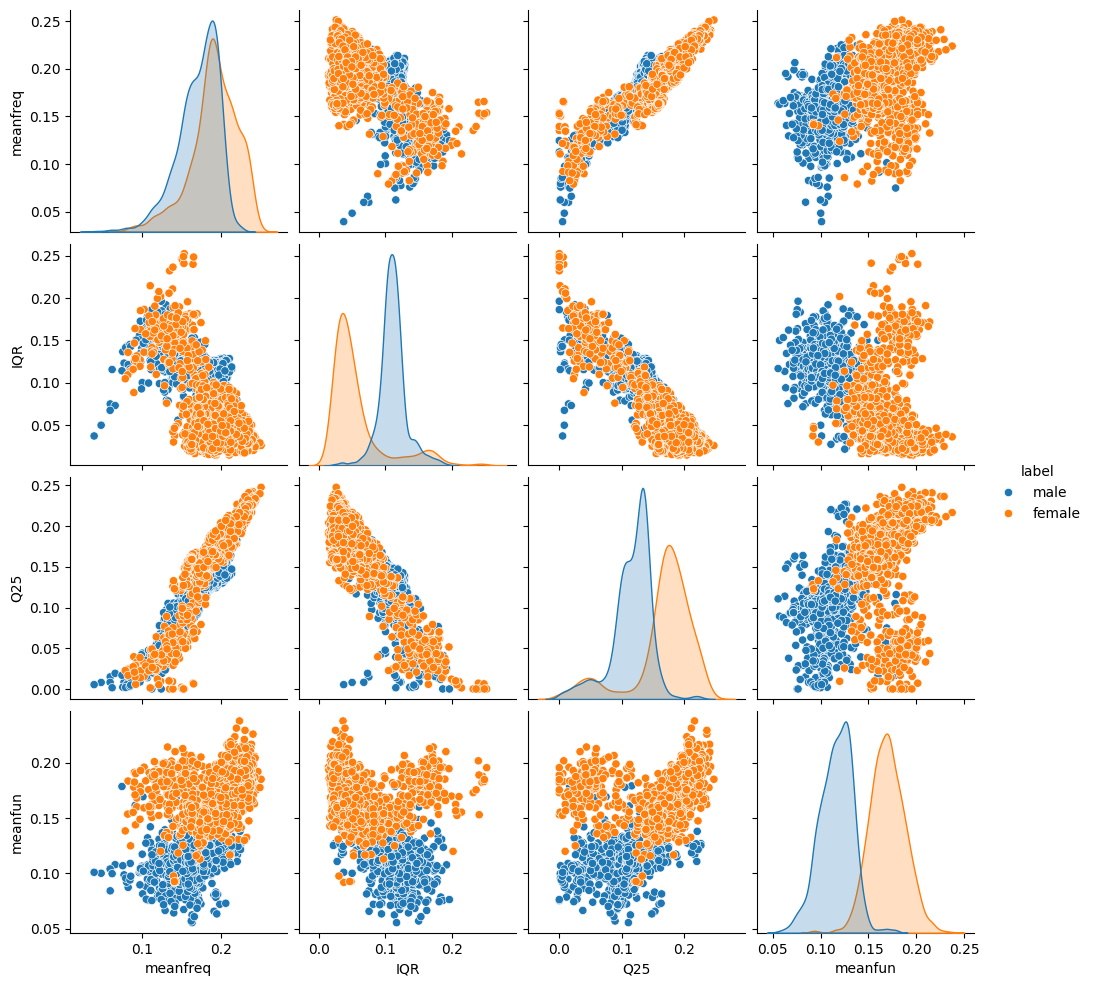

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pairplot hanya untuk beberapa fitur agar tidak terlalu berat
sns.pairplot(data[['meanfreq', 'IQR', 'Q25', 'meanfun', 'label']], hue='label')
plt.show()

#Langkah 4 - Preprocessing

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = data.iloc[:, :-1]   # semua kolom kecuali label
y = data.iloc[:, -1]    # kolom label terakhir

# Split data (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardisasi
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Langkah 5 - Buat Model kNN

In [33]:
from sklearn.neighbors import KNeighborsClassifier

# Tentukan nilai K (misalnya 3)
knn = KNeighborsClassifier(n_neighbors=3)

# Latih model
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

#Langkah 6 - Evaluasi Model kNN

In [34]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = knn.predict(X_test)
print("Akurasi:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Laporan Klasifikasi:\n", classification_report(y_test, y_pred))

Akurasi: 0.9768664563617245
Confusion Matrix:
 [[440  12]
 [ 10 489]]
Laporan Klasifikasi:
               precision    recall  f1-score   support

      female       0.98      0.97      0.98       452
        male       0.98      0.98      0.98       499

    accuracy                           0.98       951
   macro avg       0.98      0.98      0.98       951
weighted avg       0.98      0.98      0.98       951



#Soal 2

#Langkah 1 - akurasi setiap fitur (k=3)

In [35]:
# Split ulang supaya X_train kembali berupa DataFrame (belum distandardisasi)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

acc_fitur = []
for f in X.columns:
    scaler = StandardScaler()
    X_train_f = scaler.fit_transform(X_train[[f]])
    X_test_f = scaler.transform(X_test[[f]])
    model = KNeighborsClassifier(n_neighbors=3)
    model.fit(X_train_f, y_train)
    acc_fitur.append(model.score(X_test_f, y_test))

# Urutkan fitur dari akurasi tertinggi
hasil_fitur = pd.DataFrame({'Fitur': X.columns, 'Akurasi': acc_fitur})
hasil_fitur = hasil_fitur.sort_values('Akurasi', ascending=False)
hasil_fitur

,Fitur,Akurasi
12,meanfun,0.940063
5,IQR,0.887487
3,Q25,0.858044
1,sd,0.785489
8,sp.ent,0.716088
9,sfm,0.652997
10,mode,0.635121
0,meanfreq,0.614090
11,centroid,0.614090
16,mindom,0.608833


#Langkah 2 - Menambah fitur satu per satu sesuai urutan

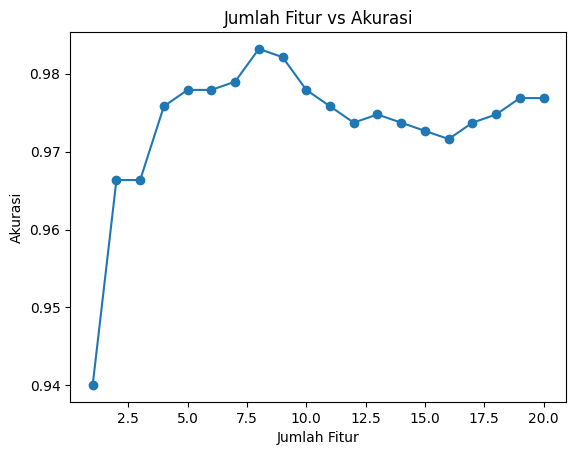

Jumlah fitur terbaik: 8
Fitur terbaik: ['meanfun', 'IQR', 'Q25', 'sd', 'sp.ent', 'sfm', 'mode', 'meanfreq']
Akurasi: 0.9831756046267087


In [36]:
urutan_fitur = hasil_fitur['Fitur'].tolist()

acc_n = []
for n in range(1, len(urutan_fitur) + 1):
    fitur_n = urutan_fitur[:n]
    scaler = StandardScaler()
    X_train_n = scaler.fit_transform(X_train[fitur_n])
    X_test_n = scaler.transform(X_test[fitur_n])
    model = KNeighborsClassifier(n_neighbors=3)
    model.fit(X_train_n, y_train)
    acc_n.append(model.score(X_test_n, y_test))

plt.plot(range(1, len(urutan_fitur) + 1), acc_n, marker='o')
plt.title('Jumlah Fitur vs Akurasi')
plt.xlabel('Jumlah Fitur')
plt.ylabel('Akurasi')
plt.show()

# Ambil jumlah fitur dengan akurasi tertinggi
n_terbaik = acc_n.index(max(acc_n)) + 1
fitur_terbaik = urutan_fitur[:n_terbaik]
print("Jumlah fitur terbaik:", n_terbaik)
print("Fitur terbaik:", fitur_terbaik)
print("Akurasi:", max(acc_n))

Standardisasi dengan fitur trbaik

In [37]:
scaler = StandardScaler()
X_train_best = scaler.fit_transform(X_train[fitur_terbaik])
X_test_best = scaler.transform(X_test[fitur_terbaik])

Saya mengurutkan fitur berdasarkan akurasi kNN masing-masing dengan k = 3, lalu menambahkannya satu per satu. Fitur paling kuat adalah meanfun (0.940), disusul IQR (0.887), Q25 (0.858), sd (0.785), sp.ent (0.716), sfm (0.653), mode (0.635), dan meanfreq (0.614). Akurasi naik dari 0.9401 (1 fitur) sampai puncak 0.9832 pada 8 fitur, lalu turun ke kisaran 0.972–0.975 dan hanya kembali ke 0.9769 saat semua 20 fitur dipakai. Jadi fitur terbaik adalah meanfun, IQR, Q25, sd, sp.ent, sfm, mode, dan meanfreq. Fitur lain tidak menambah informasi dan justru mengganggu perhitungan jarak pada kNN.

#Soal 3

#Langkah 1 - Evaluasi Nilai k

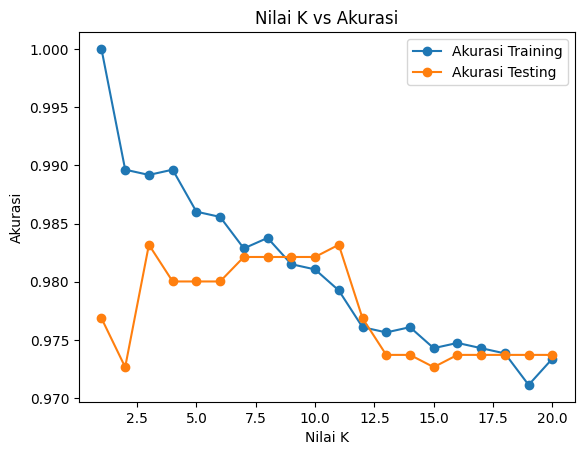

1 1.0 0.9768664563617245
2 0.9896256202074876 0.9726603575184016
3 0.9891745602165088 0.9831756046267087
4 0.9896256202074876 0.9800210304942166
5 0.9860171402796571 0.9800210304942166
6 0.9855660802886784 0.9800210304942166
7 0.9828597203428056 0.982124079915878
8 0.9837618403247632 0.982124079915878
9 0.9815065403698692 0.982124079915878
10 0.9810554803788903 0.982124079915878
11 0.9792512404149752 0.9831756046267087
12 0.9760938204781235 0.9768664563617245
13 0.9756427604871448 0.9737118822292324
14 0.9760938204781235 0.9737118822292324
15 0.9742895805142084 0.9726603575184016
16 0.9747406405051872 0.9737118822292324
17 0.9742895805142084 0.9737118822292324
18 0.9738385205232296 0.9737118822292324
19 0.9711321605773567 0.9737118822292324
20 0.9733874605322508 0.9737118822292324


In [38]:
acc_train = []
acc_test = []
for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_best, y_train)
    acc_train.append(model.score(X_train_best, y_train))
    acc_test.append(model.score(X_test_best, y_test))

plt.plot(range(1, 21), acc_train, marker='o', label='Akurasi Training')
plt.plot(range(1, 21), acc_test, marker='o', label='Akurasi Testing')
plt.title('Nilai K vs Akurasi')
plt.xlabel('Nilai K')
plt.ylabel('Akurasi')
plt.legend()
plt.show()

# Cetak akurasi untuk setiap nilai k
for k in range(1, 21):
    print(k, acc_train[k-1], acc_test[k-1])

#Langkah 2 - Evaluasi model akhir (k = 11)

In [41]:
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train_best, y_train)

y_pred = knn.predict(X_test_best)
print("Akurasi:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Laporan Klasifikasi:\n", classification_report(y_test, y_pred))

Akurasi: 0.982124079915878
Confusion Matrix:
 [[446   6]
 [ 11 488]]
Laporan Klasifikasi:
               precision    recall  f1-score   support

      female       0.98      0.99      0.98       452
        male       0.99      0.98      0.98       499

    accuracy                           0.98       951
   macro avg       0.98      0.98      0.98       951
weighted avg       0.98      0.98      0.98       951



Dengan delapan fitur tersebut, saya memilih k = 9. Pada k = 1 akurasi training 1.0 tetapi testing hanya 0.9769, tanda overfitting. Pada k = 3 akurasi testing memang tinggi (0.9832), tetapi selisihnya dengan training masih 0.6%. Mulai k = 7 sampai 10 akurasi testing stabil di 0.9821 dan garis training dan testing hampir berimpit, dengan selisih paling kecil di k = 9 (training 0.9815, testing 0.9821). Setelah k = 12 kedua akurasi turun ke sekitar 0.974 karena model terlalu sederhana. Akurasi testing k = 9 hanya berbeda 1 data dari puncak (17 vs 16 salah dari 951 data), jadi saya memilihnya karena lebih stabil dan nilainya ganjil sehingga tidak ada vote yang berimbang.